# Tutorial for BayesNDE

In this tutorial we go through the BayesNDE workflow on two simulated data sets of the paper: the involute distribution in two dimensions (the density map of Figure 2a) and the independent Gaussian mixture in 25 dimensions (Figure 4a).

BayesNDE estimates the density of an observation as the normalizing constant of its latent posterior,

$$p_{\hat\theta}(x) = \int p_{\hat\theta}(x \mid z)\, p_Z(z)\, dz ,$$

so it needs neither an invertible network nor a Jacobian determinant. The workflow has two stages:

1. **Train the Bayesian generative model** $p_\theta(x \mid z) = \mathcal{N}(\mu_\theta(z), \Sigma_\theta(z))$, $z \sim \mathcal{N}(0, I_d)$: an EGM warm start, then iterative updating of the per-sample latent variables and the generator. Checkpoints are selected on validation data only.
2. **Estimate the density of a new observation** $x$: (a) draw posterior samples of $z \mid x$ with HMC and split them into two halves; (b) fit an observation-specific mixture-of-Student-$t$ proposal with a defensive prior component on the first half; (c) combine proposal draws with the held-out half by bridge sampling.

<div class="alert alert-info">
<b>Notes</b>

- Install the environment of the repository README (Python 3.10, TensorFlow 2.15.1, TensorFlow Probability 0.23.0). A GPU is strongly recommended.
- Start Jupyter from the repository root or from `tutorial/`; the first cell puts the repository on `sys.path`.
- Both examples use the training and evaluation settings of the paper. On one GPU, training takes about 35 minutes for Example 1 and 45 minutes for Example 2. Density estimation runs its own HMC chains for every observation, and these chains are independent across observations, so parallel computation shortens the evaluation considerably. One observation at a time, the $50 \times 50$ grid of Example 1 takes about 3.5 hours and the 2,000 test points of Example 2 about 10 hours; the lockstep evaluation of Example 2, which advances the chains of 500 observations together on one GPU, takes about 20 minutes, and splitting the observations across several GPUs shortens it further. For a quicker run, lower `grid.n` in `involute_2d.yaml`.
- The configuration files are in `tutorial/configs/`, and all outputs are written below `outputs/tutorial/`.
</div>

In [1]:
import json
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import yaml
from scipy.stats import spearmanr
from tqdm.auto import tqdm

REPO = Path.cwd().resolve()
if not (REPO / "bayesnde").is_dir():
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
CONFIG_DIR = REPO / "tutorial" / "configs"
tf.get_logger().setLevel("ERROR")

from bayesnde.data.samplers import build_sampler
from bayesnde.diagnostics.generation import load_candidates, run_bgm_generation_diagnostics, select_pooled
from bayesnde.estimators.bridge import BGM_BridgeDensityEstimator
from bayesnde.estimators.pointwise import load_keras_weights_compat
from bayesnde.evaluation.grid import create_2d_slice_grid
from bayesnde.training.generation_optimized import build_bgm_model, train_egm_with_diagnostics
from bayesnde.training.iterative import current_learning_rates, encode_data_batched, set_optimizer_lr

gpus = [tf.config.experimental.get_device_details(gpu).get("device_name", gpu.name)
        for gpu in tf.config.list_physical_devices("GPU")]
print("TensorFlow", tf.__version__, "| GPU:", gpus)

TensorFlow 2.15.1 | GPU: ['NVIDIA L40S']


## Configuring BayesNDE

A run is described by one YAML file. Its sections follow the conventions of `configs/model.yaml` and `configs/bridge.yaml`, so they can be passed to the package functions directly:

| Section | Used by | Content |
|:--|:--|:--|
| `data` | `build_sampler` | simulated data set and its seed |
| `model` | `build_bgm_model` | architecture and loss weights of the Bayesian generative model |
| `training` | stage 1 | length and checkpoint interval of the EGM warm start |
| `iterative` | stage 2 | length, checkpoint grid, optimizer and extra loss weights of iterative updating |
| `generation_diagnostics` | checkpoint selection | number of generated samples compared with the validation data |
| `hmc_settings` | density estimation (a) | HMC posterior sampling |
| `density_bridge_eval` | density estimation (b), (c) | adaptive proposal and bridge sampling |
| `grid`, `evaluation` | evaluation | density-map grid, number of test points |

The `model` parameters, with the symbols of Section 3.5 and Appendix A.4 of the paper:

| Parameter | Description |
|:--|:--|
| `x_dim`, `z_dim` | Data and latent dimension. |
| `g_network_type`, `e_network_type` | `mlp` (five width-256 hidden layers, used for $p \le 10$) or `residual` (five width-256 residual blocks, used for $p > 10$). |
| `g_units`, `e_units`, `dx_units`, `dz_units` | Hidden widths of the generator $G_\theta$, the encoder $E$, and the data and latent discriminators. |
| `lr` | Learning rate of the EGM warm start. |
| `lr_theta`, `lr_z` | Learning rates of $\theta$ and of the latent variables during iterative updating. |
| `g_adv_weight`, `e_adv_weight` | $\lambda_{\mathrm{adv},x}$, $\lambda_{\mathrm{adv},z}$: adversarial losses, Eq. (24). |
| `x_cycle_weight`, `z_cycle_weight` | $\lambda_{\mathrm{rec},x}$, $\lambda_{\mathrm{rec},z}$: reconstruction losses, Eq. (25). |
| `decorrelation_weight` | $\lambda_{\mathrm{corr}}$: correlation matching, Eq. (26). |
| `marginal_mmd_weight`, `joint_mmd_weight`, `sliced_wasserstein_weight` | $\lambda_{\mathrm{MMD,marg}}$, $\lambda_{\mathrm{MMD,joint}}$, $\lambda_{\mathrm{SW}}$: Eqs. (27)-(29). |
| `variance_log_target_weight`, `variance_log_target` | $\lambda_{\mathrm{var}}$ and the target of the conditional-variance regularization, Eq. (30). |

The `iterative` parameters `iterative_prior_mmd_weight` and `iterative_empirical_corr_weight` are $\lambda_{\mathrm{PP}}$ and $\lambda^{\mathrm{iter}}_{\mathrm{corr}}$ of Eq. (32); `optimizer` and `weight_decay` set the optimizer of iterative updating (the EGM warm start always uses Adam).

In [2]:
def load_config(name):
    cfg = yaml.safe_load(open(CONFIG_DIR / name))
    cfg["model"]["output_dir"] = str(REPO / cfg["model"]["output_dir"])
    return cfg

## Building blocks

The three functions below are the stages of BayesNDE. They only orchestrate modules of the package, and the two examples call them with different configurations.

### Stage 1: EGM warm start

`train_egm_with_diagnostics` trains the generator, the encoder and the two discriminators on the EGM objective of Eq. (22) for `egm_n_iter` steps. Every `egm_batches_per_eval` steps it saves a checkpoint and compares 5,000 generated samples with the validation data by eight two-sample diagnostics. The selected checkpoint is the one with the smallest equal-weight average percentile rank over the eight diagnostics, Eq. (33); the rule looks at neither the test data nor the true density.

In [3]:
def run_egm(cfg, sampler):
    # Stage 1: EGM warm start; returns the selected checkpoint (weight files) and all checkpoints.
    tr = cfg["training"]
    model = build_bgm_model(cfg["model"], timestamp="egm", random_seed=cfg["model"]["random_seed"])

    def report(row):
        diag_file = Path(row["diagnostics_dir"]) / "generation_diagnostics.json"
        diag = json.loads(diag_file.read_text())["generated_sample"]["two_sample_vs_validation"]
        print(f"step {row['step']:>6}  l2_x={row['losses']['l2_x']:.4f}  l2_z={row['losses']['l2_z']:.4f}  "
              f"| validation: mmd={diag['mmd_rbf']:.2e} ks={diag['ks_stat_mean']:.3f} "
              f"lisi={diag['lisi_normalized_mean']:.3f}")

    rows = train_egm_with_diagnostics(
        model=model, train_data=np.asarray(sampler.X_train, dtype=np.float32), sampler=sampler, config=cfg,
        diagnostics_root=Path(cfg["model"]["output_dir"]) / "egm", max_steps=tr["egm_n_iter"],
        batch_size=tr["batch_size"], every=tr["egm_batches_per_eval"],
        earliest_stop=tr["egm_n_iter"] + 1, patience=tr["egm_n_iter"] + 1,  # no early stopping
        seed=cfg["model"]["random_seed"], callback=report)

    ranked = select_pooled(load_candidates([row["diagnostics_dir"] for row in rows], "step"),
                           cfg["data"]["dim"], key="step")
    selected = next(row for row in rows if row["step"] == ranked["step"])
    print(f"selected EGM step: {selected['step']} (rule: rank)")
    return selected, rows

### Stage 2: iterative updating

Starting from the selected EGM checkpoint, every latent variable is initialized at the encoder output, $z_i = E(x_i)$. Each epoch then alternates, minibatch by minibatch, a generator step on Eq. (32) (the conditional negative log-likelihood plus the prior-predictive MMD and the variance regularization, followed by the correlation-matching step) and a latent step on the negative log posterior of Eq. (31). This is the loop of `bayesnde/training/iterative.py`. At every epoch in `save_epochs` the generator is saved and compared with the validation data; the epoch is chosen by the rank rule of Eq. (33).

In [4]:
def run_iterative(cfg, sampler, egm_checkpoint):
    # Stage 2: iterative updating; returns the model at the selected epoch and the selection record.
    it = cfg["iterative"]
    X = np.asarray(sampler.X_train, dtype=np.float32)
    params = dict(cfg["model"])
    params.update({key: it[key] for key in (
        "optimizer", "weight_decay", "iterative_prior_mmd_weight", "iterative_empirical_corr_weight")})
    use_corr = params["iterative_empirical_corr_weight"] > 0
    if use_corr:
        params["iterative_empirical_corr_target"] = np.corrcoef(X.astype(np.float64), rowvar=False).tolist()

    model = build_bgm_model(params, timestamp="iterative", random_seed=params["random_seed"])
    load_keras_weights_compat(model.g_net, egm_checkpoint["generator_weights"])
    load_keras_weights_compat(model.e_net, egm_checkpoint["encoder_weights"])
    for net in (model.e_net, model.dz_net, model.dx_net):
        net.trainable = False
    model.data_z = tf.Variable(encode_data_batched(model=model, data=X), trainable=True)  # z_i = E(x_i)

    checkpoint_dir = Path(model.checkpoint_path)
    stage_root = Path(params["output_dir"]) / "iterative"
    rng = np.random.default_rng(it["seed"])
    batch_size, stage_dirs = it["batch_size"], []
    for epoch in range(it["epochs"] + 1):
        lr_theta, lr_z = current_learning_rates(
            epoch=epoch, lr_theta0=params["lr_theta"], lr_z0=params["lr_z"], schedule=it["lr_schedule"],
            power=it["lr_decay_power"], timescale=it["lr_decay_timescale"])
        set_optimizer_lr(model.g_optimizer, lr_theta)
        set_optimizer_lr(model.posterior_optimizer, lr_z)
        loss_x, loss_z = [], []
        if epoch > 0:
            order = rng.permutation(len(X))
            for start in range(0, len(X) - batch_size + 1, batch_size):
                idx = order[start:start + batch_size]
                batch_z = tf.Variable(tf.gather(model.data_z, idx, axis=0), trainable=True)
                loss_x.append(float(model.update_g_net(batch_z, X[idx])))                 # theta step, Eq. (32)
                if use_corr:
                    model.update_iterative_empirical_corr(X[idx])
                loss_z.append(float(model.update_latent_variable_sgd(batch_z, X[idx])))   # z step, Eq. (31)
                model.data_z.scatter_nd_update(indices=tf.expand_dims(idx, axis=1), updates=batch_z)
        if epoch in it["save_epochs"]:
            model.g_net.save_weights(str(checkpoint_dir / f"weights_at_{epoch}_generator.weights.h5"))
            stage_dir = stage_root / f"stage_epoch_{epoch:04d}"
            diag = run_bgm_generation_diagnostics(model=model, sampler=sampler, run_dir=stage_dir, config=cfg,
                                                  seed=cfg["data"]["seed"] + 31415 + epoch)
            stage_dirs.append(stage_dir)
            two = diag["generated_sample"]["two_sample_vs_validation"]
            losses = f"loss_x={np.mean(loss_x):.4f}  loss_z={np.mean(loss_z):.4f}  " if loss_x else ""
            print(f"epoch {epoch:>5}  {losses}| validation: mmd={two['mmd_rbf']:.2e} "
                  f"ks={two['ks_stat_mean']:.3f} lisi={two['lisi_normalized_mean']:.3f}")

    selection = select_pooled(load_candidates(stage_dirs, "epoch"), cfg["data"]["dim"], key="epoch")
    selection["generator_weights"] = str(checkpoint_dir / f"weights_at_{selection['epoch']}_generator.weights.h5")
    selection["encoder_weights"] = egm_checkpoint["encoder_weights"]
    load_keras_weights_compat(model.g_net, selection["generator_weights"])
    print(f"selected epoch: {selection['epoch']} (rule: rank)")
    return model, selection

### Stage 3: density estimation

`BGM_BridgeDensityEstimator.estimate` returns $\log \hat p_{\hat\theta}(x)$ for one observation. It samples $p_{\hat\theta}(z \mid x)$ with HMC, splits the draws, fits the defensive mixture-of-Student-$t$ proposal on one half, and estimates the normalizing constant by the bridge fixed point of Eq. (9). The helper below loops over observations, as the evaluation code of the experiments does.

| Setting | Description |
|:--|:--|
| `hmc_settings` | `M` retained draws over `num_chains` chains after `burn_in` transitions per chain; `step_size` is adapted during the first 80% of burn-in toward `target_accept_prob`; `num_leapfrog_steps` per transition; chains start at $E(x)$ plus noise of scale `initial_state_scale`. |
| `density_bridge_eval` | `K`-component full-covariance GMM on the fitting half, turned into Student-$t$ components with `nu` degrees of freedom and mixed with the prior with weight `epsilon`; `S` proposal draws; `fit_fraction` of the posterior draws fits the proposal; `use_neff` weights the bridge by the effective sample size; `tol`, `max_iter` stop the fixed point; `variance_floor` bounds the decoder variance; `seed` seeds a fresh estimator every `rng_block_size` points. |

In [5]:
def estimate_log_density(model, X, cfg, desc="bridge sampling"):
    # Stage 3: bridge-sampling log p(x) for each row of X, with the HMC acceptance rate.
    dens, hmc = cfg["density_bridge_eval"], cfg["hmc_settings"]
    X = np.asarray(X, dtype=np.float32)
    block = dens["rng_block_size"] or len(X)
    out = {key: np.empty(len(X)) for key in ("log_px", "hmc_acceptance")}
    for i in tqdm(range(len(X)), desc=desc, mininterval=30):
        if i % block == 0:
            estimator = BGM_BridgeDensityEstimator(model=model, likelihood="gaussian", random_seed=dens["seed"],
                                                   variance_floor=dens["variance_floor"])
        result = estimator.estimate(
            X[i], K=dens["K"], S=dens["S"], nu=dens["nu"], epsilon=dens["epsilon"], n_repeats=dens["n_repeats"],
            hmc_settings=hmc, eval_batch_size=dens["eval_batch_size"], bridge_tol=dens["tol"],
            bridge_max_iter=dens["max_iter"], fit_fraction=dens["fit_fraction"], use_neff=dens["use_neff"])
        diagnostics = result["diagnostics"][0]
        out["log_px"][i] = result["log_px"]
        out["hmc_acceptance"][i] = diagnostics["hmc_acceptance_rate"]
    return out

## Example 1: involute distribution, $p = 2$

A latent angle $R \sim \mathrm{Uniform}(0, 2\pi)$ places each observation near the curve $(r \sin 2r,\ r \cos 2r)$, with $X \mid R = r \sim \mathcal{N}\big((r \sin 2r,\ r \cos 2r),\ 0.4^2 I_2\big)$, so the density is concentrated around a curved one-dimensional manifold (Figure 2a of the paper).

### Loading the configuration

In [6]:
cfg1 = load_config("involute_2d.yaml")
print(yaml.safe_dump({key: cfg1[key] for key in ("model", "training", "iterative")}, sort_keys=False))

model:
  dataset: BGM_involute
  output_dir: outputs/tutorial/involute_2d
  random_seed: 1024
  use_bnn: false
  save_model: true
  save_res: false
  x_dim: 2
  z_dim: 2
  g_network_type: mlp
  e_network_type: mlp
  g_units:
  - 256
  - 256
  - 256
  - 256
  - 256
  e_units:
  - 256
  - 256
  - 256
  - 256
  - 256
  dx_units:
  - 256
  - 256
  - 128
  - 64
  dz_units:
  - 256
  - 256
  - 128
  - 64
  lr: 0.001
  lr_theta: 1.0e-06
  lr_z: 1.0e-07
  g_d_freq: 1
  gamma: 0.0
  alpha: 0.0
  g_adv_weight: 1.0
  e_adv_weight: 1.0
  x_cycle_weight: 1.0
  z_cycle_weight: 1.0
  decorrelation_weight: 0.3
  decorrelation_target: train
  marginal_mmd_weight: 0.0
  mmd_scales:
  - 0.05
  - 0.1
  - 0.2
  - 0.5
  - 1.0
  variance_log_target: 0.01
  variance_log_target_weight: 0.01
  variance_log_eps: 1.0e-08
training:
  batch_size: 256
  egm_n_iter: 22000
  egm_batches_per_eval: 1000
iterative:
  batch_size: 256
  epochs: 3000
  save_epochs:
  - 0
  - 1
  - 10
  - 25
  - 50
  - 100
  - 200
  - 400
  

### Data preparation

`build_sampler` draws 20,000 observations and splits them 81% / 9% / 10% into training, validation and test sets. Its `get_density` method returns the reference density, an average of the Gaussian kernels over a fine grid of angles, which is used only to evaluate the estimates.

In [7]:
sampler1 = build_sampler(cfg1["data"])
X_train1, X_val1, X_test1 = sampler1.X_train, sampler1.X_val, sampler1.X_test
print(f"train {X_train1.shape}, validation {X_val1.shape}, test {X_test1.shape}")

train (16200, 2), validation (1800, 2), test (2000, 2)


### Model training

Stage 1 runs 22,000 EGM steps with a checkpoint every 1,000 steps; stage 2 runs 3,000 epochs of iterative updating. Both checkpoints are chosen by the rank rule of Eq. (33).

In [8]:
start = time.time()
egm1, egm_rows1 = run_egm(cfg1, sampler1)
print(f"stage 1: {(time.time() - start) / 60:.1f} min")

step   1000  l2_x=0.0835  l2_z=0.0152  | validation: mmd=3.56e-03 ks=0.063 lisi=0.805
step   2000  l2_x=0.0833  l2_z=0.0143  | validation: mmd=1.85e-03 ks=0.047 lisi=0.844
step   3000  l2_x=0.0647  l2_z=0.0196  | validation: mmd=9.52e-04 ks=0.030 lisi=0.898
step   4000  l2_x=0.1032  l2_z=0.0282  | validation: mmd=1.49e-03 ks=0.040 lisi=0.867
step   5000  l2_x=0.0533  l2_z=0.0235  | validation: mmd=2.18e-03 ks=0.062 lisi=0.890
step   6000  l2_x=0.1039  l2_z=0.0308  | validation: mmd=5.79e-04 ks=0.031 lisi=0.903
step   7000  l2_x=0.0967  l2_z=0.0252  | validation: mmd=1.32e-03 ks=0.037 lisi=0.875
step   8000  l2_x=0.0663  l2_z=0.0142  | validation: mmd=8.92e-04 ks=0.032 lisi=0.916
step   9000  l2_x=0.0799  l2_z=0.0172  | validation: mmd=1.28e-03 ks=0.035 lisi=0.903
step  10000  l2_x=0.1157  l2_z=0.0201  | validation: mmd=1.08e-03 ks=0.031 lisi=0.915
step  11000  l2_x=0.1072  l2_z=0.0182  | validation: mmd=1.66e-03 ks=0.036 lisi=0.882
step  12000  l2_x=0.0705  l2_z=0.0186  | validation: m

In [9]:
start = time.time()
model1, selection1 = run_iterative(cfg1, sampler1, egm1)
print(f"stage 2: {(time.time() - start) / 60:.1f} min")

epoch     0  | validation: mmd=4.91e-04 ks=0.027 lisi=0.928
epoch     1  loss_x=10.0299  loss_z=3.9695  | validation: mmd=1.10e-03 ks=0.029 lisi=0.919
epoch    10  loss_x=8.8741  loss_z=2.9527  | validation: mmd=6.89e-04 ks=0.024 lisi=0.929
epoch    25  loss_x=8.1575  loss_z=2.3246  | validation: mmd=2.55e-04 ks=0.021 lisi=0.926
epoch    50  loss_x=6.8669  loss_z=0.9935  | validation: mmd=3.98e-04 ks=0.022 lisi=0.926
epoch   100  loss_x=4.9556  loss_z=-0.6862  | validation: mmd=7.57e-04 ks=0.025 lisi=0.934
epoch   200  loss_x=4.4119  loss_z=-1.1166  | validation: mmd=7.94e-04 ks=0.033 lisi=0.933
epoch   400  loss_x=4.3462  loss_z=-1.3830  | validation: mmd=9.22e-04 ks=0.027 lisi=0.925
epoch   700  loss_x=3.8796  loss_z=-1.4501  | validation: mmd=7.06e-04 ks=0.026 lisi=0.931
epoch  1000  loss_x=4.1471  loss_z=-1.4223  | validation: mmd=1.91e-04 ks=0.026 lisi=0.923
epoch  1500  loss_x=4.4517  loss_z=-1.3690  | validation: mmd=8.46e-04 ks=0.029 lisi=0.926
epoch  2000  loss_x=4.3786  loss_

The rank score of every saved epoch (lower is better):

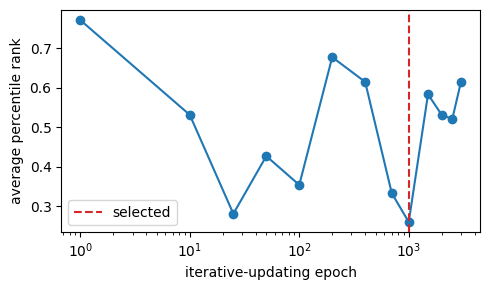

In [10]:
scores = sorted((row["epoch"], row["score"]) for row in selection1["all_scores"])
plt.figure(figsize=(5, 3))
plt.plot(*zip(*scores), marker="o")
plt.axvline(selection1["epoch"], color="tab:red", linestyle="--", label="selected")
plt.xscale("log")
plt.xlabel("iterative-updating epoch")
plt.ylabel("average percentile rank")
plt.legend()
plt.tight_layout()
plt.show()

### Generating samples

The fitted model is a generative model: $z \sim \mathcal{N}(0, I)$ and $x = \mu_\theta(z) + \sigma_\theta(z) \odot \epsilon$.

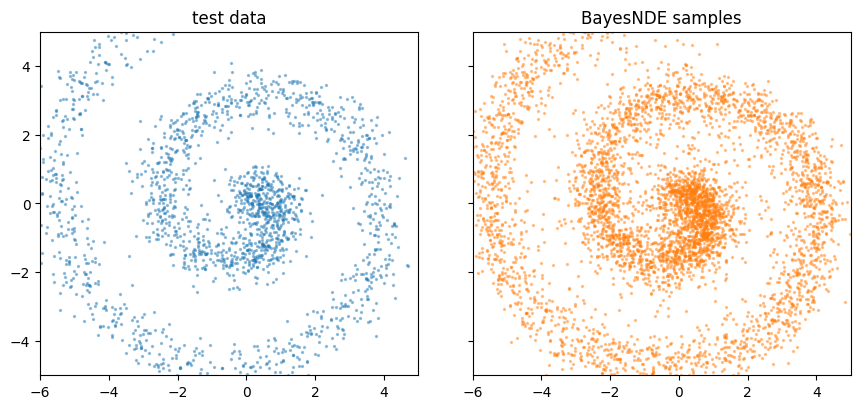

In [11]:
g = cfg1["grid"]
data_gen1, _ = model1.generate(nb_samples=5000)
data_gen1 = data_gen1.numpy()
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
axes[0].scatter(X_test1[:, 0], X_test1[:, 1], s=2, alpha=0.4)
axes[0].set_title("test data")
axes[1].scatter(data_gen1[:, 0], data_gen1[:, 1], s=2, alpha=0.4, color="tab:orange")
axes[1].set_title("BayesNDE samples")
for ax in axes:
    ax.set_xlim(g["x1_min"], g["x1_max"])
    ax.set_ylim(g["x2_min"], g["x2_max"])
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### Density estimation on a grid

As in Figure 2a, the density is evaluated on a $50 \times 50$ grid over $[-6, 5] \times [-5, 5]$ and compared with the reference density by the Spearman rank correlation over the grid.

In [12]:
v1, v2, grid = create_2d_slice_grid(cfg1["grid"], cfg1["data"])
start = time.time()
density_grid1 = estimate_log_density(model1, grid, cfg1, desc="grid")
print(f"{len(grid)} grid points in {(time.time() - start) / 60:.1f} min")

p_true_grid = sampler1.get_density(grid.astype(np.float64))
print(f"Spearman correlation with the reference density on the grid: "
      f"{spearmanr(density_grid1['log_px'], p_true_grid)[0]:.3f}")

2500 grid points in 200.2 min
Spearman correlation with the reference density on the grid: 0.961


grid: 100%|##########| 2500/2500 [3:20:10<00:00,  4.80s/it]


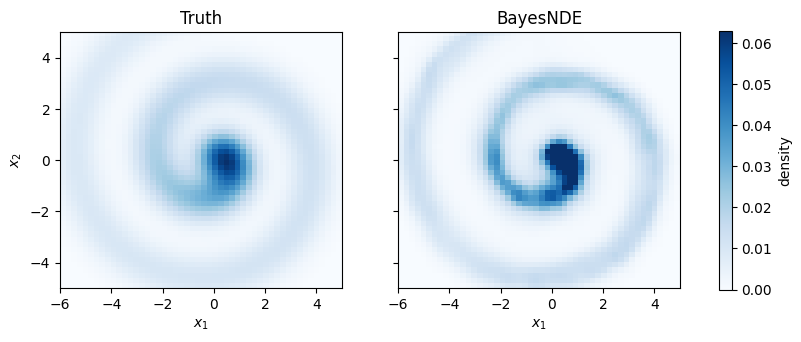

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
vmax = p_true_grid.max()
for ax, values, title in zip(axes, (p_true_grid, np.exp(density_grid1["log_px"])), ("Truth", "BayesNDE")):
    image = ax.imshow(values.reshape(v1.shape), origin="lower", cmap="Blues", vmin=0, vmax=vmax,
                      extent=(g["x1_min"], g["x1_max"], g["x2_min"], g["x2_max"]))
    ax.set_title(title)
    ax.set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
fig.colorbar(image, ax=axes, label="density", shrink=0.8)
plt.show()

### Inside the estimator: one observation

To make the three steps of Figure 1 visible, the next cell calls the methods that `BGM_BridgeDensityEstimator.estimate` runs internally, in the same order and with a freshly seeded estimator, and keeps every intermediate result:

- **(a)** HMC draws from $p_{\hat\theta}(z \mid x)$, randomly split into $\mathcal{D}_{\mathrm{fit}}$ and $\mathcal{D}_{\mathrm{bridge}}$;
- **(b)** the defensive proposal $\tilde q_x = (1 - \epsilon) q_x + \epsilon\, p_Z$ fitted to $\mathcal{D}_{\mathrm{fit}}$, and $S$ draws from it;
- **(c)** the bridge fixed-point iteration of Eq. (9).

Because the random numbers are drawn in the same order, the result equals what `estimate_log_density` returns for the same point.

In [14]:
dens, hmc = cfg1["density_bridge_eval"], cfg1["hmc_settings"]
est = BGM_BridgeDensityEstimator(model=model1, likelihood="gaussian", random_seed=dens["seed"],
                                 variance_floor=dens["variance_floor"])
x0 = X_test1[0].astype(np.float32)
x_clean, mask, _ = est._prepare_observations(x0, None)

# (a) posterior sampling and sample splitting
posterior = est.sample_posterior(x_clean, mask, hmc)
z_fit, z_bridge, _ = est._shuffle_and_split_hmc_samples(posterior.samples, fit_fraction=dens["fit_fraction"])
# (b) adaptive defensive mixture-of-Student-t proposal
proposal = est.fit_student_t_mixture(z_fit, K=dens["K"], nu=dens["nu"], epsilon=dens["epsilon"],
                                     covariance_floor=hmc["proposal_covariance_floor"])
x_tf, mask_tf = tf.constant(x_clean), tf.constant(mask)
log_pi_b, log_q_b = est._evaluate_log_pi_and_log_q(tf.constant(z_bridge, tf.float32), x_tf, mask_tf, proposal,
                                                    dens["eval_batch_size"])
ess = est._bridge_effective_sample_size(z_bridge, posterior.min_ess, dens["use_neff"])
s_p, s_q = est._bridge_sample_fractions(ess, dens["S"])
z_prop = est.sample_defensive_proposal(proposal, dens["S"])
log_pi_p, log_q_p = est._evaluate_log_pi_and_log_q(z_prop, x_tf, mask_tf, proposal, dens["eval_batch_size"])

# (c) bridge fixed point, Eq. (9), on the log scale
def log_mean_exp(values):
    return np.logaddexp.reduce(values) - np.log(len(values))

r_prop = (log_pi_p - log_q_p).numpy().astype(np.float64)    # log pi(z) - log q(z), proposal draws
r_post = (log_pi_b - log_q_b).numpy().astype(np.float64)    # the same on the held-out posterior draws
path = [log_mean_exp(r_prop)]                            # same starting value as the package
for _ in range(dens["max_iter"]):
    numerator = log_mean_exp(r_prop - np.logaddexp(np.log(s_p) + r_prop, np.log(s_q) + path[-1]))
    denominator = log_mean_exp(-np.logaddexp(np.log(s_p) + r_post, np.log(s_q) + path[-1]))
    path.append(numerator - denominator)
    if abs(path[-1] - path[-2]) < dens["tol"]:
        break

log_p_true0 = np.log(sampler1.get_density(x0[None].astype(np.float64))[0])
print(f"x = {np.round(x0, 3)};  HMC acceptance {posterior.acceptance_rate:.2f};  "
      f"effective bridge draws {ess:.0f};  s_p = {s_p:.3f}")
print(f"log p(x): bridge sampling {path[-1]:.4f} "
      f"({len(path) - 1} iterations) | reference {log_p_true0:.4f}")
same_point = estimate_log_density(model1, x0[None], cfg1, desc="same point")
print(f"estimate_log_density returns {same_point['log_px'][0]:.4f} for the same point")

x = [-4.596 -1.748];  HMC acceptance 0.80;  effective bridge draws 769;  s_p = 0.037
log p(x): bridge sampling -4.6885 (2 iterations) | reference -4.8217
estimate_log_density returns -4.6885 for the same point


same point: 100%|##########| 1/1 [00:05<00:00,  5.75s/it]


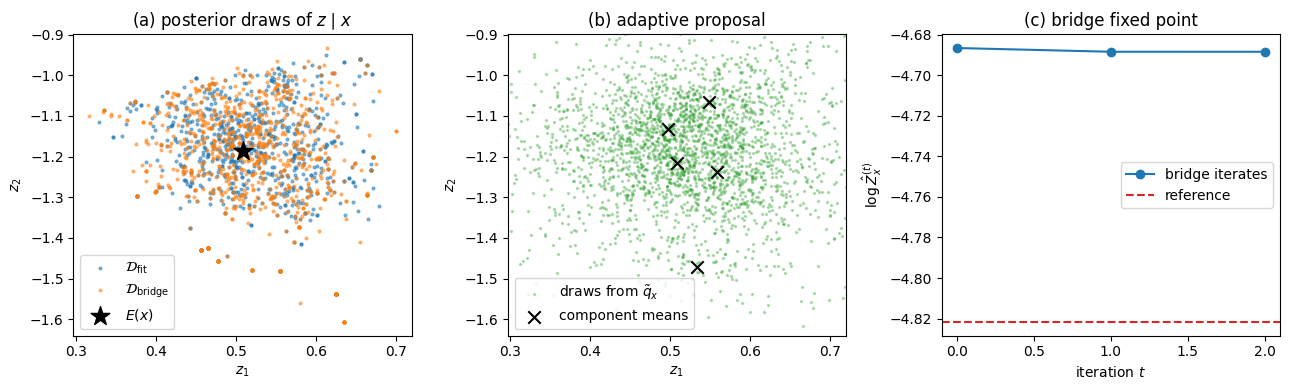

In [15]:
z_encoder = model1.e_net(x_clean, training=False).numpy()[0]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(*z_fit.T, s=4, alpha=0.5, label=r"$\mathcal{D}_{\rm fit}$")
axes[0].scatter(*z_bridge.T, s=4, alpha=0.5, label=r"$\mathcal{D}_{\rm bridge}$")
axes[0].scatter(*z_encoder, marker="*", s=200, color="black", label="$E(x)$")
axes[0].set_title(r"(a) posterior draws of $z \mid x$")
axes[0].legend()
axes[1].scatter(*z_prop.numpy()[:3000].T, s=2, alpha=0.3, color="tab:green", label=r"draws from $\tilde q_x$")
axes[1].scatter(*proposal.loc.T, marker="x", s=80, color="black", label="component means")
axes[1].set_xlim(axes[0].get_xlim())
axes[1].set_ylim(axes[0].get_ylim())
axes[1].set_title("(b) adaptive proposal")
axes[1].legend()
for ax in axes[:2]:
    ax.set_xlabel("$z_1$")
    ax.set_ylabel("$z_2$")
axes[2].plot(path, marker="o", label="bridge iterates")
axes[2].axhline(log_p_true0, color="tab:red", linestyle="--", label="reference")
axes[2].set_xlabel("iteration $t$")
axes[2].set_ylabel(r"$\log \hat Z_x^{(t)}$")
axes[2].set_title("(c) bridge fixed point")
axes[2].legend()
plt.tight_layout()
plt.show()

## Example 2: independent Gaussian mixture, $p = 25$

The second example is the independent Gaussian mixture of the paper: each coordinate independently follows $\tfrac13\mathcal{N}(-1, 0.1^2) + \tfrac13\mathcal{N}(0, 0.1^2) + \tfrac13\mathcal{N}(1, 0.1^2)$. In 25 dimensions it has $3^{25} \approx 8.5 \times 10^{11}$ modes, so the training data cover only a tiny fraction of them.

### Loading the configuration and the data

In [16]:
cfg25 = load_config("indep_gmm_25d.yaml")
print(yaml.safe_dump({key: cfg25[key] for key in ("model", "training")}, sort_keys=False))

sampler25 = build_sampler(cfg25["data"])
X_train25, X_val25, X_test25 = sampler25.X_train, sampler25.X_val, sampler25.X_test
print(f"train {X_train25.shape}, validation {X_val25.shape}, test {X_test25.shape}")

model:
  dataset: BGM_indep_gmm
  output_dir: outputs/tutorial/indep_gmm_25d
  random_seed: 1024
  use_bnn: false
  save_model: true
  save_res: false
  x_dim: 25
  z_dim: 25
  g_network_type: residual
  e_network_type: residual
  g_units:
  - 256
  - 256
  - 256
  - 256
  - 256
  e_units:
  - 256
  - 256
  - 256
  - 256
  - 256
  dx_units:
  - 256
  - 256
  - 128
  - 64
  dz_units:
  - 256
  - 256
  - 128
  - 64
  lr: 0.001
  lr_theta: 0.005
  lr_z: 0.005
  g_d_freq: 1
  gamma: 0.0
  alpha: 0.0
  g_adv_weight: 1.0
  e_adv_weight: 1.0
  x_cycle_weight: 3.0
  z_cycle_weight: 1.0
  decorrelation_weight: 0.3
  decorrelation_target: train
  marginal_mmd_weight: 1000.0
  mmd_scales:
  - 0.05
  - 0.1
  - 0.2
  - 0.5
  - 1.0
  joint_mmd_weight: 100.0
  sliced_wasserstein_weight: 300.0
  sliced_wasserstein_projections: 64
  sliced_wasserstein_seed: 20260831
  variance_log_target: 0.01
  variance_log_target_weight: 0.0
  variance_log_eps: 1.0e-08
training:
  batch_size: 256
  egm_n_iter: 3000
 

### Model training

Stage 1 runs 3,000 EGM steps with a checkpoint every 50 steps; stage 2 runs 2,000 epochs of iterative updating. Both checkpoints are chosen by the rank rule of Eq. (33).

In [17]:
start = time.time()
egm25, egm_rows25 = run_egm(cfg25, sampler25)
print(f"stage 1: {(time.time() - start) / 60:.1f} min")

step     50  l2_x=0.8610  l2_z=1.0806  | validation: mmd=1.06e-02 ks=0.181 lisi=0.582
step    100  l2_x=0.7385  l2_z=0.8544  | validation: mmd=1.03e-02 ks=0.169 lisi=0.425
step    150  l2_x=0.7022  l2_z=0.9259  | validation: mmd=1.46e-02 ks=0.162 lisi=0.332
step    200  l2_x=0.6905  l2_z=0.8778  | validation: mmd=1.65e-02 ks=0.158 lisi=0.289
step    250  l2_x=0.6474  l2_z=0.9184  | validation: mmd=1.53e-02 ks=0.149 lisi=0.271
step    300  l2_x=0.6855  l2_z=0.8909  | validation: mmd=1.94e-02 ks=0.162 lisi=0.255
step    350  l2_x=0.7022  l2_z=0.8866  | validation: mmd=1.80e-02 ks=0.152 lisi=0.252
step    400  l2_x=0.6993  l2_z=0.8667  | validation: mmd=1.77e-02 ks=0.132 lisi=0.243
step    450  l2_x=0.7715  l2_z=0.8747  | validation: mmd=2.00e-02 ks=0.145 lisi=0.235
step    500  l2_x=0.7994  l2_z=0.8860  | validation: mmd=1.88e-02 ks=0.140 lisi=0.239
step    550  l2_x=0.8065  l2_z=0.9150  | validation: mmd=1.97e-02 ks=0.136 lisi=0.229
step    600  l2_x=0.8510  l2_z=0.9010  | validation: m

In [18]:
start = time.time()
model25, selection25 = run_iterative(cfg25, sampler25, egm25)
print(f"stage 2: {(time.time() - start) / 60:.1f} min")

epoch     0  | validation: mmd=2.03e-02 ks=0.080 lisi=0.192
epoch     1  loss_x=1126.1519  loss_z=27.8549  | validation: mmd=4.13e-02 ks=0.179 lisi=0.724
epoch     5  loss_x=85.0769  loss_z=12.8463  | validation: mmd=1.37e-02 ks=0.145 lisi=0.701
epoch    10  loss_x=83.1946  loss_z=10.5286  | validation: mmd=1.38e-02 ks=0.167 lisi=0.756
epoch    20  loss_x=73.2030  loss_z=1.6728  | validation: mmd=2.30e-02 ks=0.159 lisi=0.594
epoch    30  loss_x=71.3497  loss_z=0.4421  | validation: mmd=2.43e-02 ks=0.156 lisi=0.495
epoch    40  loss_x=69.2970  loss_z=-1.3192  | validation: mmd=2.01e-02 ks=0.149 lisi=0.562
epoch    50  loss_x=68.0238  loss_z=-2.3521  | validation: mmd=2.49e-02 ks=0.156 lisi=0.492
epoch    75  loss_x=64.1196  loss_z=-5.9047  | validation: mmd=2.58e-02 ks=0.157 lisi=0.457
epoch   100  loss_x=60.5897  loss_z=-9.4882  | validation: mmd=2.61e-02 ks=0.161 lisi=0.452
epoch   150  loss_x=55.3001  loss_z=-14.0218  | validation: mmd=2.26e-02 ks=0.156 lisi=0.477
epoch   200  loss_x

### Density estimation on test observations

We estimate the log density of all 2,000 test observations, as in the paper, and compare it with the true log density.

`estimate_log_density` treats one observation at a time, so each HMC step only evaluates the decoder on four chains and the GPU is mostly idle; for 2,000 points in 25 dimensions this takes about 10 hours. The cell below runs the same estimator with the HMC chains of 500 observations advancing together on one GPU (lockstep), which takes about 20 minutes. Each observation keeps its own adapted HMC step size, and the sample splitting, proposal fitting and bridge sampling still run per observation through `BGM_BridgeDensityEstimator.estimate`, so the estimates agree with `estimate_log_density` up to Monte Carlo error.

In [19]:
import tensorflow_probability as tfp
from bayesnde.estimators.pointwise import HMCResult


def estimate_log_density_lockstep(model, X, cfg, batch_points=500, desc="lockstep"):
    # Stage 3 on one GPU: the HMC chains of `batch_points` observations advance together, each
    # observation with its own adapted step size; proposal fitting and bridge sampling then run
    # per observation through BGM_BridgeDensityEstimator.estimate, exactly as in estimate_log_density.
    dens, hmc = cfg["density_bridge_eval"], cfg["hmc_settings"]
    X = np.asarray(X, dtype=np.float32)
    chains, burn_in = hmc["num_chains"], hmc["burn_in"]
    n_results = int(np.ceil(hmc["M"] / chains))

    class LockstepEstimator(BGM_BridgeDensityEstimator):
        def sample_posterior(self, x_clean, obs_mask_flat, hmc_settings):
            return self.pending.pop(0)  # draws of this observation from the lockstep chains

    estimator = LockstepEstimator(model=model, likelihood="gaussian", random_seed=dens["seed"],
                                  variance_floor=dens["variance_floor"])

    @tf.function(reduce_retracing=True)
    def run_chains(x, init, seed):
        n_points = tf.shape(init)[0]

        def target_log_prob(z):  # z: (points, chains, z_dim) -> (points, chains)
            x_rep = tf.repeat(x, chains, axis=0)
            flat = tf.reshape(z, [-1, tf.shape(z)[-1]])
            return tf.reshape(estimator.log_joint(flat, x_rep, tf.ones_like(x_rep, tf.bool)), [n_points, chains])

        step = tf.fill([n_points, 1, 1], tf.constant(hmc["step_size"], tf.float32))  # one step size per observation
        kernel = tfp.mcmc.SimpleStepSizeAdaptation(
            tfp.mcmc.HamiltonianMonteCarlo(target_log_prob, step_size=step, num_leapfrog_steps=hmc["num_leapfrog_steps"]),
            num_adaptation_steps=int(0.8 * burn_in), target_accept_prob=hmc["target_accept_prob"])
        return tfp.mcmc.sample_chain(n_results, init, kernel=kernel, num_burnin_steps=burn_in, seed=seed,
                                     trace_fn=lambda _, pkr: pkr.inner_results.is_accepted)

    out = {key: np.empty(len(X)) for key in ("log_px", "hmc_acceptance")}
    for start in tqdm(range(0, len(X), batch_points), desc=desc):
        xb = X[start:start + batch_points]
        z0 = model.e_net(xb, training=False)  # chains start at E(x) plus small noise, as in the package
        noise = tf.random.stateless_normal([len(xb), chains, z0.shape[-1]], seed=[dens["seed"], 2 * start])
        init = z0[:, None, :] + hmc["initial_state_scale"] * noise
        samples, accepted = run_chains(tf.constant(xb), init, tf.constant([dens["seed"], 2 * start + 1]))
        samples = samples.numpy()  # (results, points, chains, z_dim)
        ess = np.maximum(tfp.mcmc.effective_sample_size(samples).numpy().sum(axis=1), 1.0)  # (points, z_dim)
        acceptance = accepted.numpy().mean(axis=(0, 2))
        estimator.pending = [
            HMCResult(samples=samples[:, p].reshape(-1, samples.shape[-1]), acceptance_rate=float(acceptance[p]),
                      ess_per_dim=ess[p], min_ess=float(ess[p].min()), mean_ess=float(ess[p].mean()),
                      requested_samples=hmc["M"], retained_samples=n_results * chains, num_chains=chains,
                      burn_in=burn_in, step_size=hmc["step_size"], num_leapfrog_steps=hmc["num_leapfrog_steps"],
                      attempts=1)
            for p in range(len(xb))]
        for p in range(len(xb)):
            result = estimator.estimate(
                xb[p], K=dens["K"], S=dens["S"], nu=dens["nu"], epsilon=dens["epsilon"], n_repeats=dens["n_repeats"],
                hmc_settings=hmc, eval_batch_size=dens["eval_batch_size"], bridge_tol=dens["tol"],
                bridge_max_iter=dens["max_iter"], fit_fraction=dens["fit_fraction"], use_neff=dens["use_neff"])
            out["log_px"][start + p] = result["log_px"]
            out["hmc_acceptance"][start + p] = acceptance[p]
    return out


n_test25 = cfg25["evaluation"]["test_points"]
rng = np.random.default_rng(cfg25["evaluation"]["test_seed"])
test_idx25 = np.sort(rng.choice(len(X_test25), size=n_test25, replace=False))

start = time.time()
density_test25 = estimate_log_density_lockstep(model25, X_test25[test_idx25], cfg25)
# one observation at a time, about 30 times slower: estimate_log_density(model25, X_test25[test_idx25], cfg25)
print(f"{n_test25} test points in {(time.time() - start) / 60:.1f} min on one GPU")
log_p_true25 = sampler25.get_log_density(X_test25[test_idx25])

print(f"Spearman correlation with the true density: {spearmanr(density_test25['log_px'], log_p_true25)[0]:.3f}")
print(f"median HMC acceptance rate: {np.median(density_test25['hmc_acceptance']):.2f}")

2000 test points in 19.0 min on one GPU
Spearman correlation with the true density: 0.594
median HMC acceptance rate: 0.74


lockstep: 100%|##########| 4/4 [19:01<00:00, 285.38s/it]


### Reusing a trained model

The checkpoints stay on disk, so a trained model can be rebuilt later for density estimation only: build the network from the same `model` config and load the selected generator and the EGM encoder.

In [20]:
print("generator:", os.path.relpath(selection25["generator_weights"], REPO))
print("encoder:  ", os.path.relpath(selection25["encoder_weights"], REPO))

reloaded = build_bgm_model({**cfg25["model"], "save_model": False}, timestamp="reload",
                           random_seed=cfg25["model"]["random_seed"])
load_keras_weights_compat(reloaded.g_net, selection25["generator_weights"])
load_keras_weights_compat(reloaded.e_net, selection25["encoder_weights"])

x_check = X_test25[test_idx25[:3]]
check_trained = estimate_log_density(model25, x_check, cfg25, desc="trained model")
check_reloaded = estimate_log_density(reloaded, x_check, cfg25, desc="reloaded model")
print("trained model: ", np.round(check_trained["log_px"], 4))
print("reloaded model:", np.round(check_reloaded["log_px"], 4))

generator: outputs/tutorial/indep_gmm_25d/checkpoints/BGM_indep_gmm/iterative/weights_at_1950_generator.weights.h5
encoder:   outputs/tutorial/indep_gmm_25d/checkpoints/BGM_indep_gmm/egm/weights_at_egm_init_2900_encoder.weights.h5
trained model:  [-18.5484 -17.0116 -13.3804]
reloaded model: [-18.5484 -17.0116 -13.3804]


reloaded model: 100%|##########| 3/3 [00:54<00:00, 18.14s/it]
